In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch import nn
from src.utils import get_dataset, get_diffusion_schedule_nickname, get_diffusion_weights, get_n_qubits_from_data, set_device, get_path
from src.QDDPM_torch_angel import QDDPMDiffuser
from tqdm import tqdm
import pytorch_optimizer
from functools import partial
from livelossplot import PlotLosses
from opt_einsum import contract
import qutip as qt
from qutip import Bloch
from src.QDDPM_torch_angel import WassDistance
from sklearn.model_selection import train_test_split
import yaml
from train_mlp_conditioned import TimeConditionedMLP, sample, DataGenerator

def bloch_xyz(inputs):
    # obtain bloch sphere representation vector
    rho = contract('mi,mj->mij', inputs, inputs.conj())
    sigmas = [qt.sigmax().full(), qt.sigmay().full(), qt.sigmaz().full()]
    pos = [np.real(contract('mii->m', contract('mij,jk->mik', rho, x))) for x in sigmas]
    return pos

def ndim_cluster0Gen(n_data, n_qubits, epsilon, rng=None):
    states0 = np.zeros((n_data, 2**n_qubits), dtype=np.complex64)
    states0[:, 0] = 1.
    states1 = np.zeros((n_data, 2**n_qubits), dtype=np.complex64)
    states1[:, 1] = 1.

    re_c = rng.normal(loc=0.0, scale=1.0, size=n_data)
    im_c = rng.normal(loc=0.0, scale=1.0, size=n_data)
    c = re_c + 1j*im_c
    c = c[:, np.newaxis]
    states = states0 + epsilon*c*states1
    states /= np.linalg.norm(states, axis=1, keepdims=True)
    
    return states  

savedir = Path('results/TimeConditionedMLP/CIRCLEY_1/nhidden10_hiddendim16')
config = yaml.safe_load(open(savedir / 'config.yaml', 'r'))
batch_size = 100

n_qubits = int(config["dataset"]["name"].split('_')[1])
n_features = 2**n_qubits
diffusion_schedule_nickname = get_diffusion_schedule_nickname(config)
n_data = config['dataset']['n_data']
n_timesteps = config['model']['n_timesteps']
device = set_device(config.get('device', 'cpu'))
# get_path_partial = partial(get_path, config, modeltype='MLP', diffusion_schedule_nickname=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)

Using device: cuda:0


# Sampling

/tmp/ipykernel_1534610/3396679408.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)
100%|██████████| 20/20 [00:07<00:00,  2.84it/s]


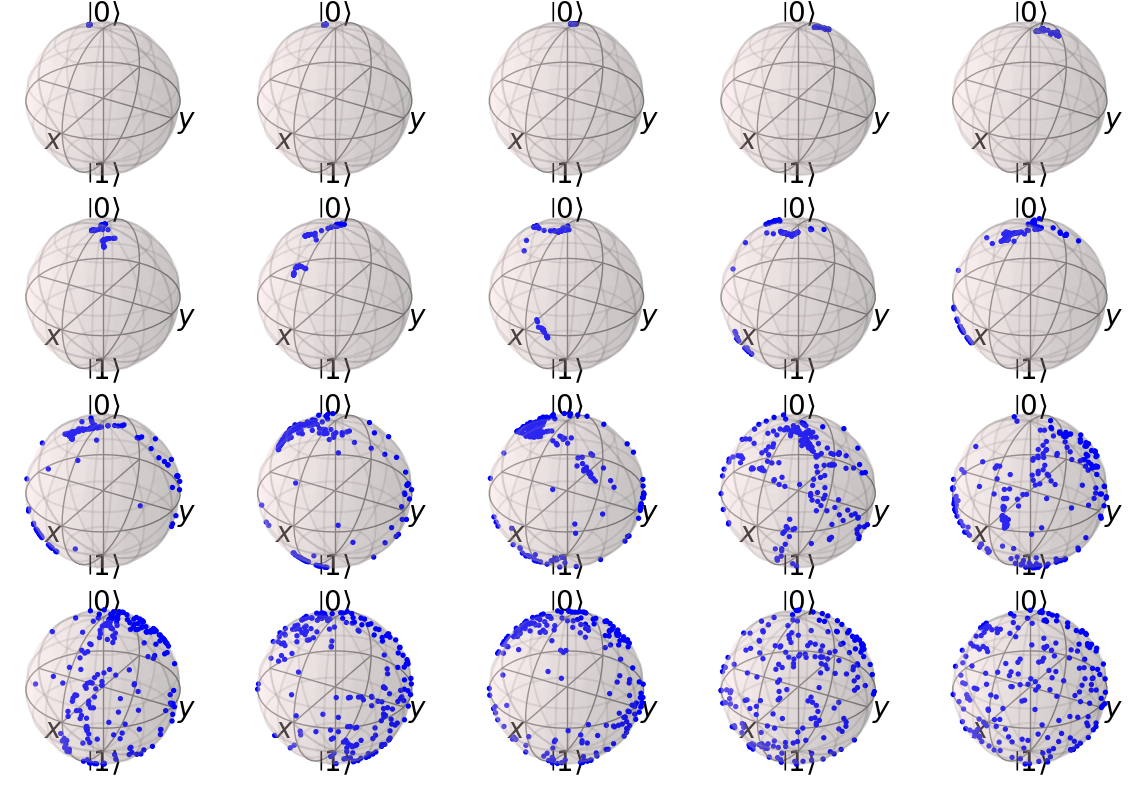

In [3]:
# Bloch visualize on the forward noise process
device = 'cpu'
diffuser = QDDPMDiffuser(config=config, n_data=n_data, n_timesteps=n_timesteps, n_features=n_features, device=device)
diffusion_weights = get_diffusion_weights(config, device=device)
seed = config["seed"]+1 # Use a different seed so it's test data
rng = np.random.default_rng(seed)
datagen = DataGenerator(config, diffuser, diffusion_weights, rng, n_features=n_features, device=device)
states_diffused = datagen.generate(n_timesteps)
model = TimeConditionedMLP(**config['model']['params'], activation=nn.ReLU).to(device)
path = savedir / 'models' / 'val_bestmodel.pt'
checkpoint = torch.load(path)
model.load_state_dict(checkpoint['model_state_dict'])

cols = 5
fig, axs = plt.subplots(n_timesteps//cols, cols, figsize=(12, 8), subplot_kw={'projection': '3d'})
states = states_diffused[-1]
model.eval()
for i in tqdm(range(n_timesteps, 0, -1)):
    xs0, ys0, zs0 = bloch_xyz(states.numpy())
    b0 = Bloch(fig=fig, axes=axs[(i-1)//cols, (i-1)%cols])
    b0.clear()
    b0.add_points([xs0, ys0, zs0])
    b0.point_color = ['b']*n_data
    b0.point_style = 'm'
    b0.point_size = 8*np.ones(n_data)
    b0.render()

    with torch.no_grad():
        timesteps = i*torch.ones(states.shape[0], dtype=torch.int32, device=device)
        states = model(states, timesteps)
plt.tight_layout()

# Perfect input

/tmp/ipykernel_1534610/4058922647.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)
100%|██████████| 20/20 [00:07<00:00,  2.55it/s]


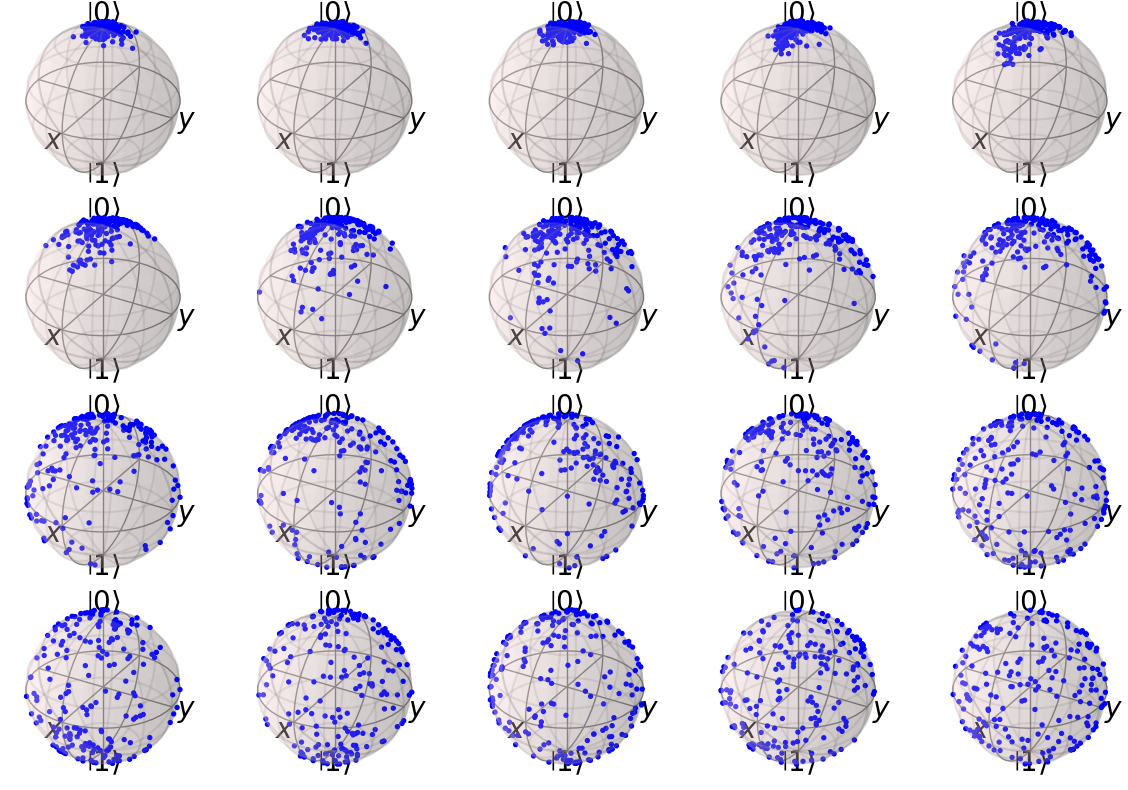

In [4]:
# Bloch visualize on the forward noise process
device = 'cpu'
diffuser = QDDPMDiffuser(config=config, n_data=n_data, n_timesteps=n_timesteps, n_features=n_features, device=device)
diffusion_weights = get_diffusion_weights(config, device=device)
seed = config["seed"]+1 # Use a different seed so it's test data
rng = np.random.default_rng(seed)
datagen = DataGenerator(config, diffuser, diffusion_weights, rng, n_features=n_features, device=device)
states_diffused = datagen.generate(n_timesteps)
model = TimeConditionedMLP(**config['model']['params'], activation=nn.ReLU).to(device)
path = savedir / 'models' / 'val_bestmodel.pt'
checkpoint = torch.load(path)
model.load_state_dict(checkpoint['model_state_dict'])

cols = 5
fig, axs = plt.subplots(n_timesteps//cols, cols, figsize=(12, 8), subplot_kw={'projection': '3d'})
states = states_diffused[-1]
model.eval()
for i in tqdm(range(n_timesteps, 0, -1)):
    xs0, ys0, zs0 = bloch_xyz(states.numpy())
    b0 = Bloch(fig=fig, axes=axs[(i-1)//cols, (i-1)%cols])
    b0.clear()
    b0.add_points([xs0, ys0, zs0])
    b0.point_color = ['b']*n_data
    b0.point_style = 'm'
    b0.point_size = 8*np.ones(n_data)
    b0.render()

    with torch.no_grad():
        timesteps = i*torch.ones(states.shape[0], dtype=torch.int32, device=device)
        states = model(states_diffused[i], timesteps)
plt.tight_layout()

# Forward plot

/tmp/ipykernel_1534610/3640661151.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)
100%|██████████| 20/20 [00:07<00:00,  2.70it/s]


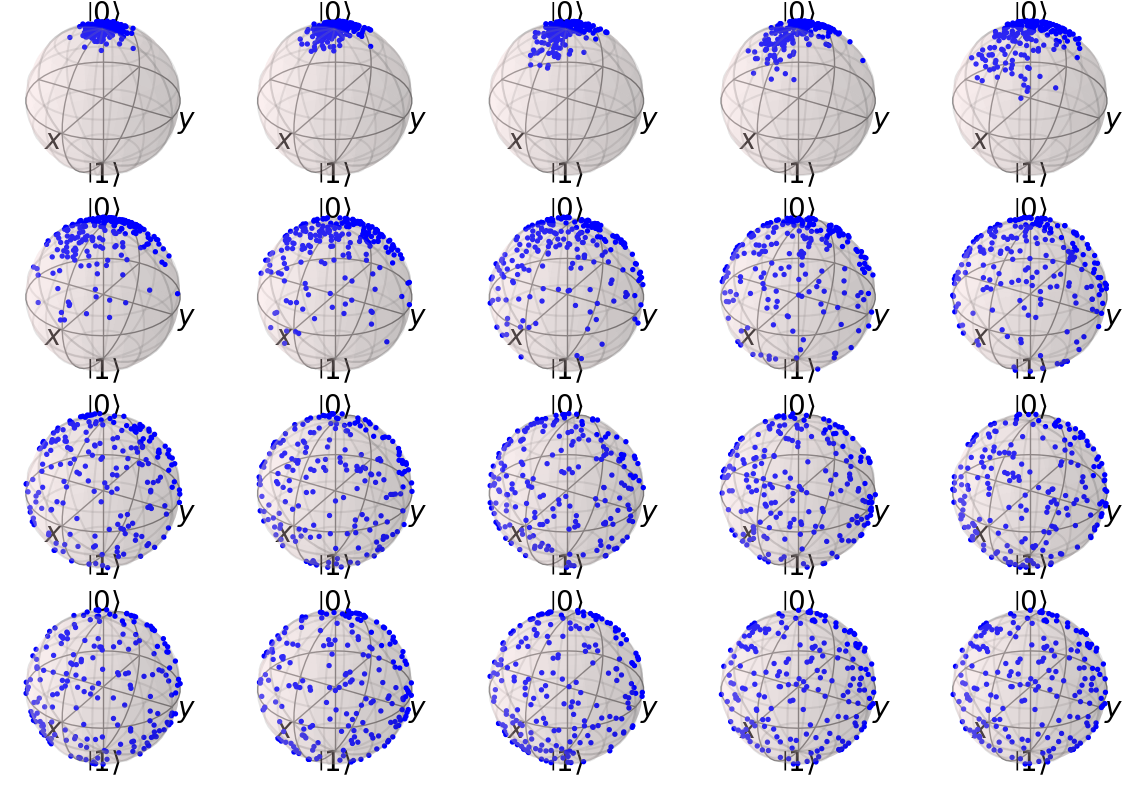

In [5]:
# Bloch visualize on the forward noise process
device = 'cpu'
diffuser = QDDPMDiffuser(config=config, n_data=n_data, n_timesteps=n_timesteps, n_features=n_features, device=device)
diffusion_weights = get_diffusion_weights(config, device=device)
seed = config["seed"]+1 # Use a different seed so it's test data
rng = np.random.default_rng(seed)
datagen = DataGenerator(config, diffuser, diffusion_weights, rng, n_features=n_features, device=device)
states_diffused = datagen.generate(n_timesteps)
model = TimeConditionedMLP(**config['model']['params'], activation=nn.ReLU).to(device)
path = savedir / 'models' / 'val_bestmodel.pt'
checkpoint = torch.load(path)
model.load_state_dict(checkpoint['model_state_dict'])

cols = 5
fig, axs = plt.subplots(n_timesteps//cols, cols, figsize=(12, 8), subplot_kw={'projection': '3d'})
states = states_diffused[-1]
model.eval()
for i in tqdm(range(n_timesteps, 0, -1)):
    xs0, ys0, zs0 = bloch_xyz(states.numpy())
    b0 = Bloch(fig=fig, axes=axs[(i-1)//cols, (i-1)%cols])
    b0.clear()
    b0.add_points([xs0, ys0, zs0])
    b0.point_color = ['b']*n_data
    b0.point_style = 'm'
    b0.point_size = 8*np.ones(n_data)
    b0.render()

    with torch.no_grad():
        timesteps = i*torch.ones(states.shape[0], dtype=torch.int32, device=device)
        states = states_diffused[i]
plt.tight_layout()

# Sampling with an additional stochastic term

/tmp/ipykernel_469870/3816659344.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)
100%|██████████| 20/20 [00:06<00:00,  3.09it/s]


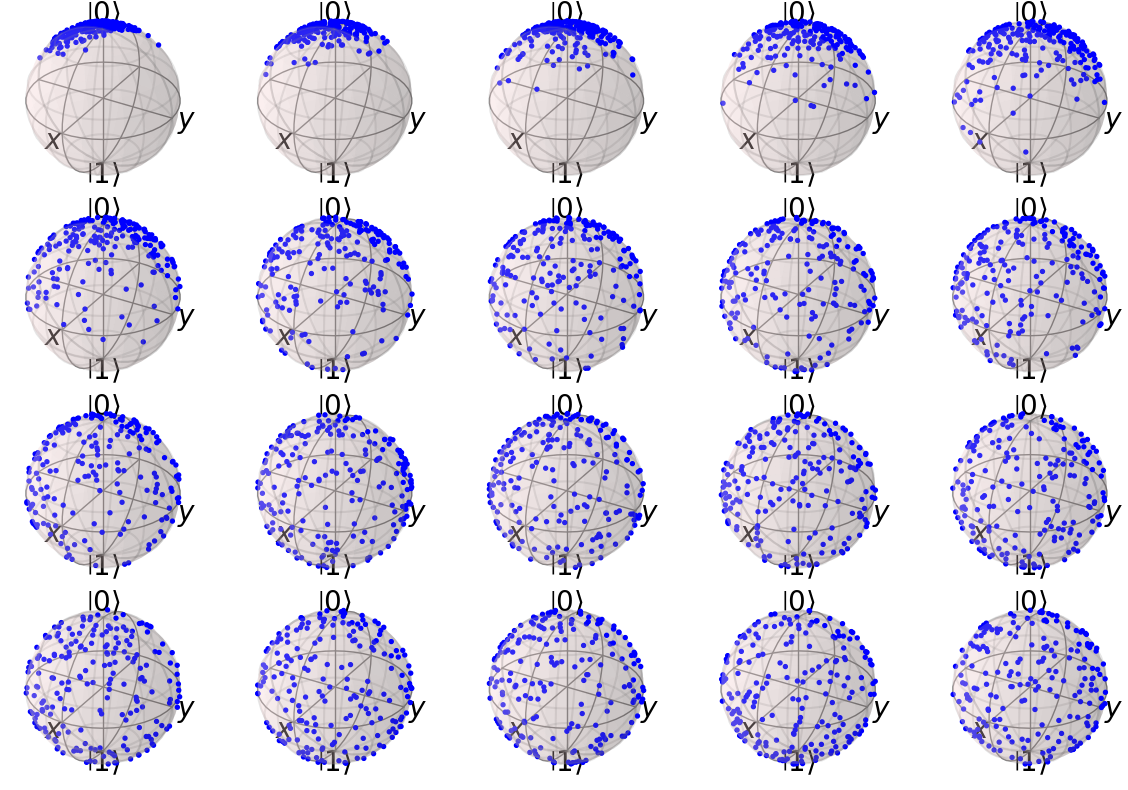

In [2]:
# Bloch visualize on the forward noise process
device = 'cpu'
diffuser = QDDPMDiffuser(config=config, n_data=n_data, n_timesteps=n_timesteps, n_features=n_features, device=device)
diffusion_weights = get_diffusion_weights(config, device=device)
seed = config["seed"]+1 # Use a different seed so it's test data
rng = np.random.default_rng(seed)
datagen = DataGenerator(config, diffuser, diffusion_weights, rng, n_features=n_features, device=device)
states_diffused = datagen.generate(n_timesteps)
model = TimeConditionedMLP(**config['model']['params'], activation=nn.ReLU).to(device)
path = savedir / 'models' / 'val_bestmodel.pt'
checkpoint = torch.load(path)
model.load_state_dict(checkpoint['model_state_dict'])

cols = 5
fig, axs = plt.subplots(n_timesteps//cols, cols, figsize=(12, 8), subplot_kw={'projection': '3d'})
states = states_diffused[-1]
model.eval()
for i in tqdm(range(n_timesteps, 0, -1)):
    xs0, ys0, zs0 = bloch_xyz(states.numpy())
    b0 = Bloch(fig=fig, axes=axs[(i-1)//cols, (i-1)%cols])
    b0.clear()
    b0.add_points([xs0, ys0, zs0])
    b0.point_color = ['b']*n_data
    b0.point_style = 'm'
    b0.point_size = 8*np.ones(n_data)
    b0.render()

    with torch.no_grad():
        timesteps = i*torch.ones(states.shape[0], dtype=torch.int32, device=device)
        states = model(states, timesteps)

        # We add the stochasticity here.
        sigmas = torch.pow(diffusion_weights / torch.max(diffusion_weights), 1)
        states = states + torch.randn_like(states) * sigmas[i]
        states = states / torch.linalg.norm(states, dim=1, keepdim=True)

        
plt.tight_layout()